In [1]:
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSeq2SeqLM

c:\Users\HP\OneDrive\Desktop\ML Project\Text_generation_Topsis\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

In [2]:
text_prompt = "Artificial intelligence will change the world because"
model_registry = {
    "GPT2": "gpt2",
    "DistilGPT2": "distilgpt2",
    "T5Small": "t5-small",
    "BARTBase": "facebook/bart-base"
}

evaluation_records = []

# Model Evaluation Loop

In [3]:
for label, hf_name in model_registry.items():
    print(f"\nRunning evaluation for {label}")

    if "t5" in hf_name or "bart" in hf_name:
        tokenizer = AutoTokenizer.from_pretrained(hf_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(hf_name)
        prepared_text = "generate text: " + text_prompt
    else:
        tokenizer = AutoTokenizer.from_pretrained(hf_name)
        model = AutoModelForCausalLM.from_pretrained(hf_name)
        prepared_text = text_prompt

    encoded = tokenizer(prepared_text, return_tensors="pt")

    start = time.perf_counter()
    with torch.no_grad():
        generated_ids = model.generate(
            **encoded,
            max_length=60,
            do_sample=True,
            top_k=40
        )
    end = time.perf_counter()

    elapsed_time = end - start
    decoded_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    word_count = len(decoded_text.split())

    total_params = sum(p.numel() for p in model.parameters())
    size_mb = (total_params * 4) / (1024 ** 2)

    with torch.no_grad():
        loss_val = model(**encoded, labels=encoded["input_ids"]).loss
    perplexity_val = torch.exp(loss_val).item()

    evaluation_records.append([
        label,
        word_count,
        elapsed_time,
        size_mb,
        perplexity_val
    ])



Running evaluation for GPT2


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 353.30it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Running evaluation for DistilGPT2


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 356.22it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Running evaluation for T5Small


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 477.23it/s, Materializing param=shared.weight]                                                      



Running evaluation for BARTBase


Loading weights: 100%|██████████| 259/259 [00:00<00:00, 510.16it/s, Materializing param=model.shared.weight]                                  


# Decision Matrix

In [4]:
columns = ["Model", "Quality", "Latency", "ModelSize", "Perplexity"]
df = pd.DataFrame(evaluation_records, columns=columns)

print("\nDecision Matrix:\n")
print(df)


Decision Matrix:

        Model  Quality   Latency   ModelSize  Perplexity
0        GPT2       51  8.754249  474.700195   61.544209
1  DistilGPT2       46  3.401283  312.471680  122.721542
2     T5Small        1  0.495023  230.814453   15.438724
3    BARTBase        9  3.018249  531.846680    1.001720


# Custom TOPSIS Implementation

In [5]:
data = df.iloc[:, 1:].to_numpy(dtype=float)

importance = np.array([0.30, 0.25, 0.20, 0.25])
nature = np.array([1, -1, -1, -1])  # benefit / cost

# Vector normalization
denominator = np.sqrt((data ** 2).sum(axis=0))
normalized = data / denominator

# Apply weights
weighted_data = normalized * importance

# Identify ideal solutions
ideal_positive = []
ideal_negative = []

for j in range(weighted_data.shape[1]):
    if nature[j] == 1:
        ideal_positive.append(weighted_data[:, j].max())
        ideal_negative.append(weighted_data[:, j].min())
    else:
        ideal_positive.append(weighted_data[:, j].min())
        ideal_negative.append(weighted_data[:, j].max())

ideal_positive = np.array(ideal_positive)
ideal_negative = np.array(ideal_negative)

# Distance calculation
dist_pos = np.sqrt(((weighted_data - ideal_positive) ** 2).sum(axis=1))
dist_neg = np.sqrt(((weighted_data - ideal_negative) ** 2).sum(axis=1))

# Closeness coefficient
closeness = dist_neg / (dist_pos + dist_neg)

df["TOPSIS_Score"] = closeness
df = df.sort_values("TOPSIS_Score", ascending=False)

print("\nFinal Ranking (TOPSIS):\n")
print(df[["Model", "TOPSIS_Score"]])


Final Ranking (TOPSIS):

        Model  TOPSIS_Score
2     T5Small      0.574743
3    BARTBase      0.562971
1  DistilGPT2      0.509774
0        GPT2      0.500055


# Visualization

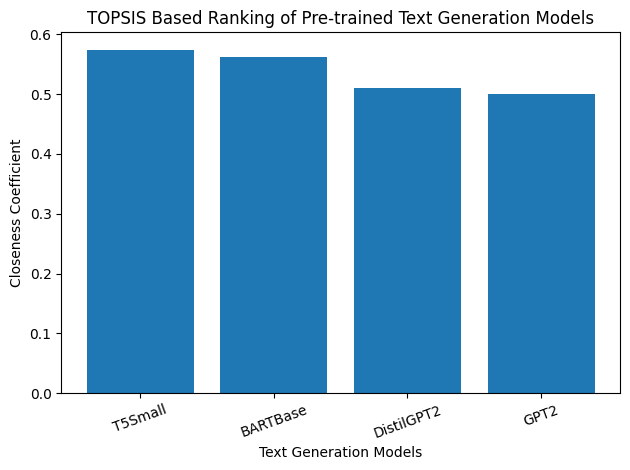

In [6]:
plt.figure()
plt.bar(df["Model"], df["TOPSIS_Score"])
plt.xlabel("Text Generation Models")
plt.ylabel("Closeness Coefficient")
plt.title("TOPSIS Based Ranking of Pre-trained Text Generation Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()